# Trend Analysis Dashboard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from utils import (
    fetch_prices, fetch_index,
    calc_monthly_returns,
    calc_trend_regime, calc_regime_stats,
    calc_trend_quintile,
    calc_momentum_signals, calc_quintile_from_signals,
    grid_search_regime, grid_search_quintile, grid_search_regime_weights,
    plot_quadrant_scatter, plot_quadrant_trajectory, plot_regime_stats,
    regime_weighted_backtest, equal_weight_backtest,
    summarize_strategy, plot_strategy_backtest,
)

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

In [2]:
# ---- Configuration ----
proxy = None #"http://46.2.90.210:8080"

# Ticker list & display names
tickers = [
    "SMH", "IGV", "XAR", "XBI", "XME", "GDX", "XOP", "PAVE",
    "MGK", "MGV", "IWM", "SCHD", "USMV", "MTUM", "QUAL",
    "372330.KS", "487230.KS", "BOTZ", "SKYY", "ICLN", "AIQ"
]

ticker_names = {
    "SMH":       "Semiconductors",
    "IGV":       "Software",
    "XAR":       "Aerospace",
    "XBI":       "Biotech",
    "XME":       "Metals&Mining",
    "GDX":       "GoldMiners",
    "XOP":       "Oil&Gas",
    "PAVE":      "InfraDev",
    "MGK":       "Growth",
    "MGV":       "Value",
    "IWM":       "Small",
    "SCHD":      "Dividend",
    "USMV":      "MinVol",
    "MTUM":      "Momentum",
    "QUAL":      "Quality",
    "372330.KS": "HangSengTech",
    "487230.KS": "AI-Power",
    "BOTZ":      "Robot",
    "SKYY":      "CloudComputing",
    "ICLN":      "CleanEnergy",
    "AIQ":       "AI-Tech"
}

# Trend lookback (months)
fast_months = 3
slow_months = 10

# Composite rank weights
w_slow = 0.5
w_fast = 0.5

# Snapshot date for Quadrant Scatter (None = latest available month-end)
# e.g. "2024-12-31" or "2024-12" — picks the nearest month-end ≤ this date
#snapshot_date = "2026-03-31"
snapshot_date = None

## 1. Trend Cycle Quadrant Analysis

In [3]:
prices_multi = fetch_prices(tickers, start="1900-01-01", end="2026-12-31", proxy=proxy)
monthly_ret_multi = calc_monthly_returns(prices_multi)
regimes = calc_trend_regime(monthly_ret_multi, fast_months=fast_months, slow_months=slow_months)

# Resolve snapshot date: None → latest, otherwise nearest month-end ≤ snapshot_date
all_dates = regimes["date"]
if snapshot_date is None:
    snap_date = all_dates.max()
else:
    target = pd.Timestamp(snapshot_date)
    eligible = all_dates[all_dates <= target]
    if len(eligible) == 0:
        raise ValueError(f"No regime data on/before {snapshot_date}; earliest available is {all_dates.min().date()}")
    snap_date = eligible.max()

latest_date = snap_date  # kept name for downstream cells
latest = regimes[regimes["date"] == latest_date].copy()

print(f"Snapshot date: {latest_date.strftime('%Y-%m-%d')}  (Fast={fast_months}M, Slow={slow_months}M)")
latest[["ticker", "ret_fast", "ret_slow", "regime"]]

[*********************100%***********************]  21 of 21 completed


Snapshot date: 2026-05-31  (Fast=3M, Slow=10M)


,ticker,ret_fast,ret_slow,regime
55,372330.KS,-0.022689,-0.042583,Bearish
68,487230.KS,0.359559,0.557657,Bullish
155,AIQ,0.162555,0.312118,Bullish
262,BOTZ,-0.006920,0.162752,Correction
493,GDX,-0.259237,0.673765,Correction
699,ICLN,0.168496,0.599973,Bullish
988,IGV,0.082138,-0.209475,Rebound
1291,IWM,0.082830,0.298224,Bullish
1503,MGK,0.101501,0.122034,Bullish
1715,MGV,0.003022,0.188349,Bullish


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


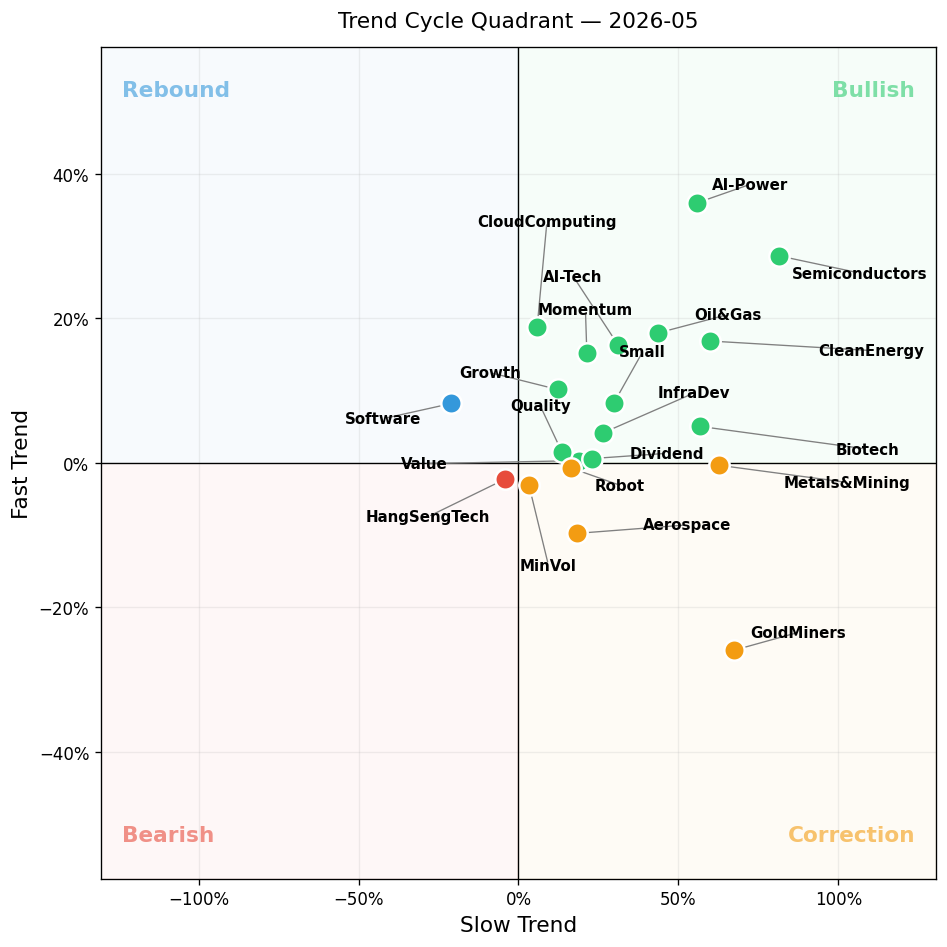

In [4]:
# Chart A: Quadrant Scatter
plot_quadrant_scatter(latest, snap_date=latest_date, ticker_names=ticker_names,
                      fast_months=fast_months, slow_months=slow_months)
plt.show()

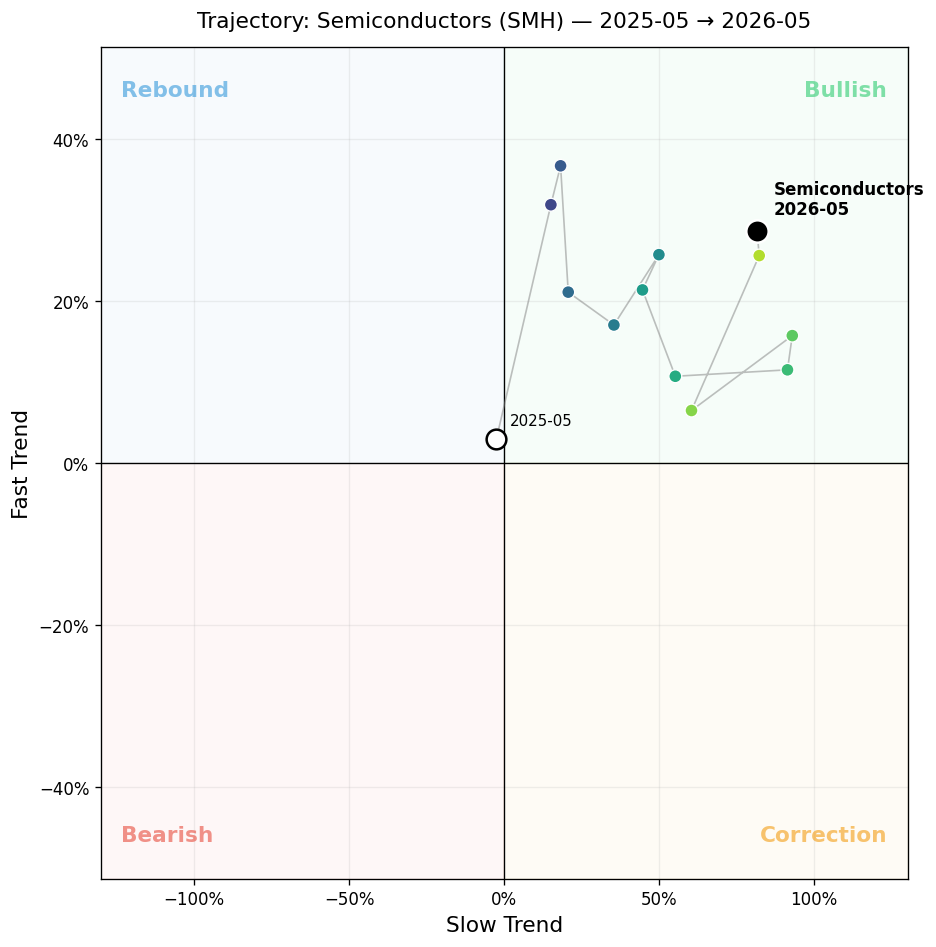

In [5]:
# Chart A2: Single-ticker trajectory through the quadrant
trajectory_ticker = "SMH"          # change to any ticker in the universe
trajectory_start = None            # e.g. "2022-01-31" (None → use lookback)
trajectory_end = snapshot_date     # None → latest available
trajectory_lookback = 12           # months back from end (ignored if start is set)

plot_quadrant_trajectory(
    regimes, ticker=trajectory_ticker, ticker_names=ticker_names,
    fast_months=fast_months, slow_months=slow_months,
    start_date=trajectory_start, end_date=trajectory_end,
    lookback_months=trajectory_lookback,
)
plt.show()

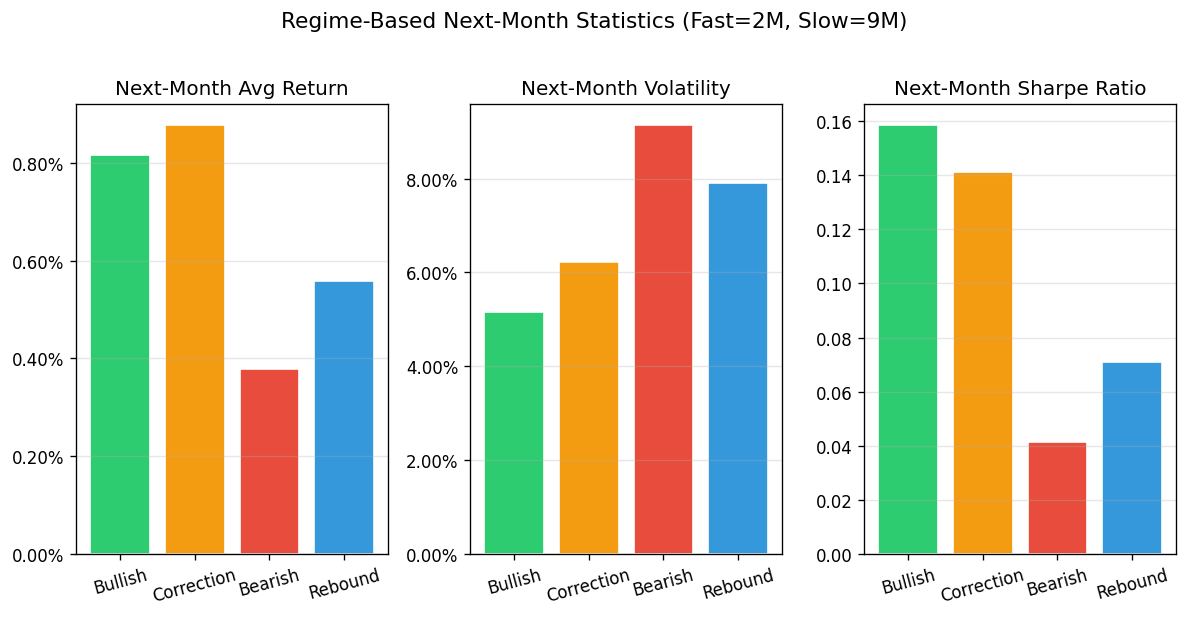

In [6]:
# Chart B: Regime Statistics
regime_stats = calc_regime_stats(monthly_ret_multi, regimes)
plot_regime_stats(regime_stats, fast_months=fast_months, slow_months=slow_months)
plt.show()

## 1b. Regime-Based Trading Strategy

매월말 자산별 regime 판별 → 가중치를 익월 한 달간 적용.
- **Bullish**: 높은 가중치 / **Correction · Rebound**: 낮은 가중치 / **Bearish**: 0
- `mode="per_asset"` (default): w_i = regime_weight[i] / N → 합계 0~1 (나머지 cash)
- `mode="normalize"`: w_i = regime_weight[i] / Σregime_weight → 항상 100% 투자 (전부 Bear면 cash)
- 회전율: 0.5 × Σ|Δw|, 거래비용: round-trip BPS × 회전율

Lookback: Fast=2M, Slow=9M | mode=normalize | tcost=20 bps
Weights: {'Bullish': 1.0, 'Correction': 0.9, 'Rebound': 0.2, 'Bearish': 0.1}
Avg monthly turnover — Strategy: 13.94%   BM: 1.03%
Avg exposure (decision-date avg):
Bullish       0.586
Correction    0.248
Rebound       0.072
Bearish       0.095
Cash          0.000


,CAGR,Vol,Sharpe,MDD,HitRate,Months
Strategy Gross,11.23%,19.83%,0.64,-46.28%,60.6%,302
Strategy Net,10.86%,19.83%,0.62,-46.52%,60.3%,302
BM 1/N Gross,9.37%,20.49%,0.54,-47.06%,59.9%,302
BM 1/N Net,9.34%,20.49%,0.54,-47.09%,59.9%,302


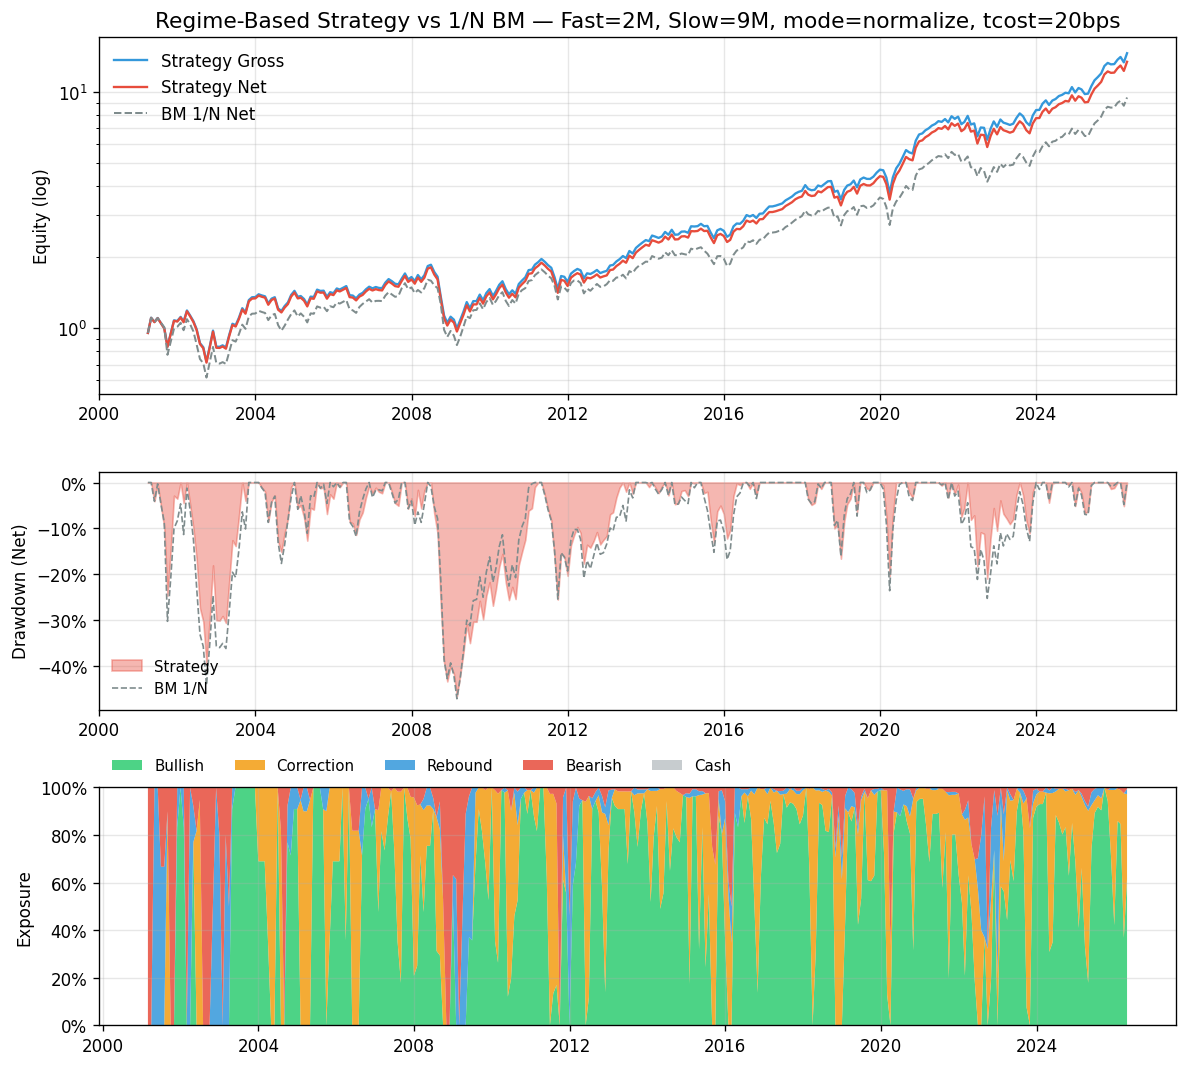

In [11]:
# ---- Strategy config ----
regime_weights_map = {
    "Bullish":    1.0,
    "Correction": 0.9,
    "Rebound":    0.2,
    "Bearish":    0.1,
}
strategy_mode = "normalize"   # "per_asset" or "normalize"
tcost_bps = 20.0              # round-trip basis points

bt = regime_weighted_backtest(
    monthly_ret_multi, regimes,
    regime_weights=regime_weights_map,
    tcost_bps=tcost_bps,
    mode=strategy_mode,
)

# Benchmark: equal-weight 1/N over live universe (same tcost)
bm = equal_weight_backtest(monthly_ret_multi, regimes, tcost_bps=tcost_bps)

summary = pd.DataFrame({
    "Strategy Gross": summarize_strategy(bt["gross_returns"]),
    "Strategy Net":   summarize_strategy(bt["net_returns"]),
    "BM 1/N Gross":   summarize_strategy(bm["gross_returns"]),
    "BM 1/N Net":     summarize_strategy(bm["net_returns"]),
}).T

avg_to = bt["turnover"].mean()
bm_to = bm["turnover"].mean()
avg_exposure = bt["regime_exposure"].mean()
print(f"Lookback: Fast={fast_months}M, Slow={slow_months}M | mode={strategy_mode} | tcost={tcost_bps:.0f} bps")
print(f"Weights: {regime_weights_map}")
print(f"Avg monthly turnover — Strategy: {avg_to*100:.2f}%   BM: {bm_to*100:.2f}%")
print(f"Avg exposure (decision-date avg):")
print(avg_exposure.round(3).to_string())
display(summary.style.format({
    "CAGR": "{:.2%}", "Vol": "{:.2%}", "Sharpe": "{:.2f}",
    "MDD": "{:.2%}", "HitRate": "{:.1%}", "Months": "{:.0f}"
}))

plot_strategy_backtest(
    bt,
    title=f"Regime-Based Strategy vs 1/N BM — Fast={fast_months}M, Slow={slow_months}M, mode={strategy_mode}, tcost={tcost_bps:.0f}bps",
    benchmark=bm,
    benchmark_label="BM 1/N",
)
plt.show()

## 1c. Optimize regime_weights_map (Grid Search)

`regime_weights_map`의 4 가중치 모두 0.1 step으로 그리드 서치 → net Sharpe 최대화 조합 탐색.

- `Bullish`, `Correction`, `Rebound`, `Bearish` ∈ [0.0, 1.0] step 0.1 → 11⁴ = **14,641 조합** (~6분 소요)
- 각 조합에서 회전율·tcost·MDD 등 모두 다시 계산. 결과는 net Sharpe 기준 정렬.
- *주의*: `mode="normalize"`에선 4 가중치를 같은 비율로 스케일하면 동일 결과 → 일부 중복 조합 존재.

Combos tested: 14641 | mode=normalize | tcost=20 bps

Top 15 by net Sharpe:


,w_Bullish,w_Correction,w_Rebound,w_Bearish,CAGR,Vol,Sharpe,MDD,HitRate,AvgTurnover
0,1.0,1.0,0.0,0.1,11.57%,20.02%,0.649,-48.87%,59.6%,18.31%
1,1.0,0.9,0.0,0.1,11.56%,20.02%,0.649,-48.78%,59.9%,18.58%
2,1.0,0.8,0.0,0.1,11.53%,20.02%,0.648,-48.68%,59.9%,19.10%
3,0.9,0.9,0.0,0.1,11.53%,20.03%,0.648,-49.04%,59.6%,18.17%
4,0.9,0.8,0.0,0.1,11.52%,20.03%,0.647,-48.94%,59.9%,18.47%
5,0.9,1.0,0.0,0.1,11.52%,20.03%,0.647,-49.12%,59.6%,18.75%
6,1.0,0.7,0.0,0.1,11.50%,20.03%,0.646,-48.56%,59.9%,19.82%
7,0.8,0.8,0.0,0.1,11.50%,20.04%,0.646,-49.23%,59.6%,17.99%
8,0.9,0.7,0.0,0.1,11.49%,20.03%,0.645,-48.82%,59.9%,19.09%
9,0.8,0.9,0.0,0.1,11.48%,20.04%,0.645,-49.32%,59.6%,18.66%


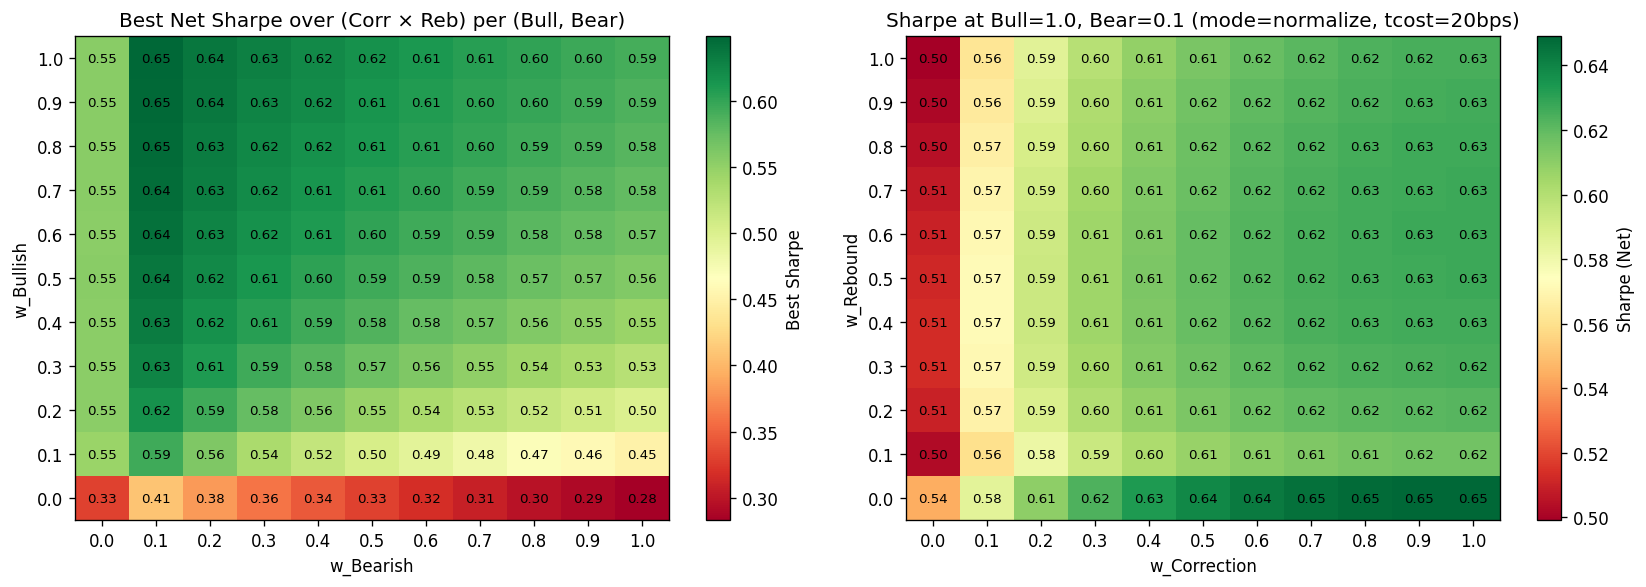

CPU times: user 6min 34s, sys: 180 ms, total: 6min 34s
Wall time: 6min 34s


In [8]:
%%time
# Grid search regime_weights_map — 4 차원 모두 [0,1] step 0.1
weights_grid = grid_search_regime_weights(
    monthly_ret_multi, regimes,
    bull_grid=None,         # 0.0~1.0 step 0.1
    correction_grid=None,
    rebound_grid=None,
    bear_grid=None,         # 0.0~1.0 step 0.1
    step=0.1,
    tcost_bps=tcost_bps,
    mode=strategy_mode,
)

print(f"Combos tested: {len(weights_grid)} | mode={strategy_mode} | tcost={tcost_bps:.0f} bps")
print(f"\nTop 15 by net Sharpe:")
display(weights_grid.head(15).style.format({
    "w_Bullish": "{:.1f}", "w_Correction": "{:.1f}",
    "w_Rebound": "{:.1f}", "w_Bearish": "{:.1f}",
    "CAGR": "{:.2%}", "Vol": "{:.2%}", "Sharpe": "{:.3f}",
    "MDD": "{:.2%}", "HitRate": "{:.1%}", "AvgTurnover": "{:.2%}",
}))

# Heatmap 1: best Sharpe per (Bull, Bear), marginalized over (Corr, Reb)
hm_bb = (weights_grid.groupby(["w_Bullish", "w_Bearish"])["Sharpe"].max()
         .unstack().sort_index(ascending=False))

# Heatmap 2: at the optimal (Bull, Bear), Sharpe over (Corr, Reb)
best = weights_grid.iloc[0]
hm_cr = (weights_grid[(weights_grid["w_Bullish"] == best["w_Bullish"]) &
                       (weights_grid["w_Bearish"] == best["w_Bearish"])]
         .pivot(index="w_Rebound", columns="w_Correction", values="Sharpe")
         .sort_index(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
im = ax.imshow(hm_bb.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(hm_bb.columns))); ax.set_xticklabels([f"{c:.1f}" for c in hm_bb.columns])
ax.set_yticks(range(len(hm_bb.index)));    ax.set_yticklabels([f"{r:.1f}" for r in hm_bb.index])
ax.set_xlabel("w_Bearish"); ax.set_ylabel("w_Bullish")
ax.set_title("Best Net Sharpe over (Corr × Reb) per (Bull, Bear)")
for i in range(len(hm_bb.index)):
    for j in range(len(hm_bb.columns)):
        v = hm_bb.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, label="Best Sharpe")

ax = axes[1]
im = ax.imshow(hm_cr.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(hm_cr.columns))); ax.set_xticklabels([f"{c:.1f}" for c in hm_cr.columns])
ax.set_yticks(range(len(hm_cr.index)));    ax.set_yticklabels([f"{r:.1f}" for r in hm_cr.index])
ax.set_xlabel("w_Correction"); ax.set_ylabel("w_Rebound")
ax.set_title(f"Sharpe at Bull={best['w_Bullish']:.1f}, Bear={best['w_Bearish']:.1f} "
             f"(mode={strategy_mode}, tcost={tcost_bps:.0f}bps)")
for i in range(len(hm_cr.index)):
    for j in range(len(hm_cr.columns)):
        v = hm_cr.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, label="Sharpe (Net)")

plt.tight_layout(); plt.show()

## 2. Trend Quintile Analysis (Rank-Based)

In [7]:
# Quintile assignment
quintile_latest, quintile_stats = calc_trend_quintile(
    monthly_ret_multi, regimes, w_slow=w_slow, w_fast=w_fast
)

# Show current quintile assignments
quintile_latest["name"] = quintile_latest["ticker"].map(ticker_names)
display(quintile_latest[["ticker", "name", "ret_fast", "ret_slow",
                          "rank_slow", "rank_fast", "rank_composite", "quintile"]]
        .sort_values("rank_composite"))
print(f"\nLookback: Fast={fast_months}M, Slow={slow_months}M | Weights: Slow={w_slow}, Fast={w_fast}")
quintile_stats

,ticker,name,ret_fast,ret_slow,rank_slow,rank_fast,rank_composite,quintile
55,372330.KS,HangSengTech,-0.022825,-0.042717,2.0,5.0,3.5,Q1
2912,USMV,MinVol,-0.037256,0.024967,4.0,3.0,3.5,Q1
262,BOTZ,Robot,-0.034854,0.130045,7.0,4.0,5.5,Q1
3079,XAR,Aerospace,-0.098677,0.180973,10.0,2.0,6.0,Q1
988,IGV,Software,0.042050,-0.238761,1.0,12.0,6.5,Q2
2109,QUAL,Quality,0.007273,0.126937,6.0,9.0,7.5,Q2
1715,MGV,Value,-0.014447,0.167652,9.0,7.0,8.0,Q2
2444,SKYY,CloudComputing,0.074966,-0.042486,3.0,14.0,8.5,Q2
2275,SCHD,Dividend,-0.006143,0.215221,11.0,8.0,9.5,Q3
1503,MGK,Growth,0.082748,0.102931,5.0,15.0,10.0,Q3



Lookback: Fast=2M, Slow=9M | Weights: Slow=0.5, Fast=0.5


,mean,std,sharpe
Q1,0.002429,0.076943,0.031565
Q2,0.008768,0.059597,0.147122
Q3,0.012434,0.062563,0.198747
Q4,0.012176,0.055314,0.220127
Q5,0.010019,0.059632,0.168007


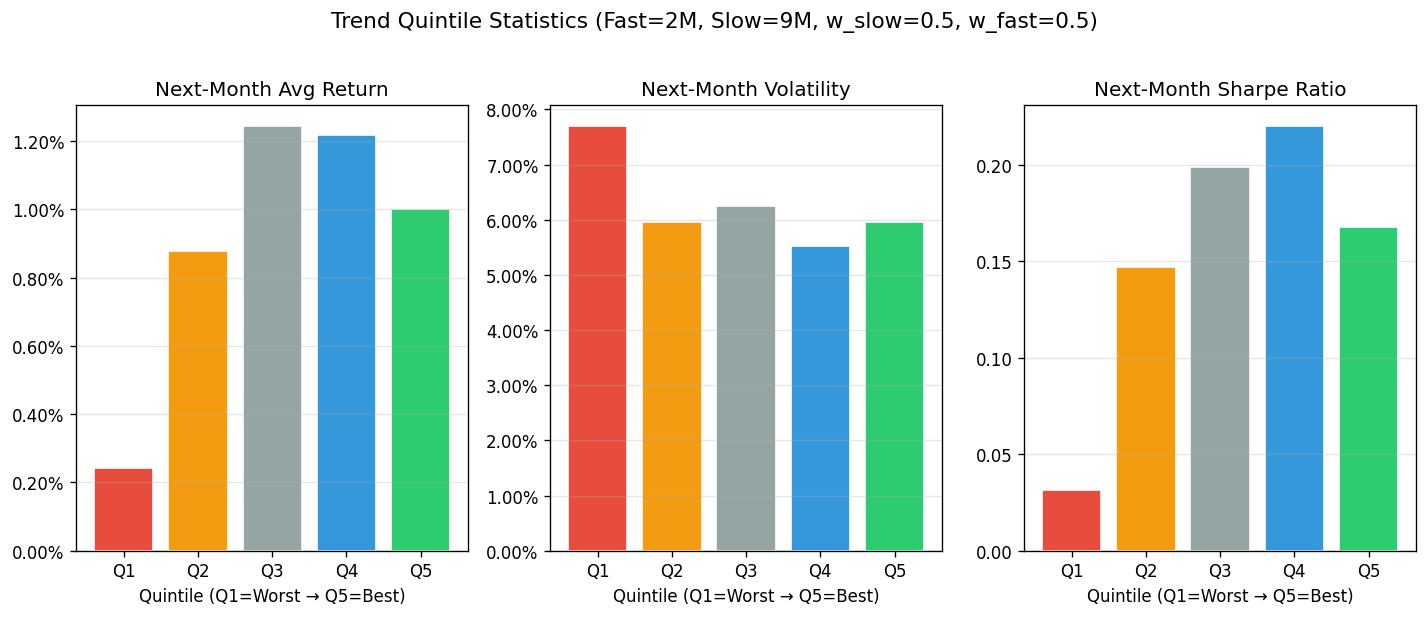

In [8]:
# Chart: Quintile Statistics
q_labels = [f"Q{i}" for i in range(1, 6)]
q_colors = ["#e74c3c", "#f39c12", "#95a5a6", "#3498db", "#2ecc71"]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Mean Return
axes[0].bar(q_labels, quintile_stats.loc[q_labels, "mean"], color=q_colors, edgecolor="white")
axes[0].set_title("Next-Month Avg Return")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].grid(axis="y", alpha=0.3)

# Volatility
axes[1].bar(q_labels, quintile_stats.loc[q_labels, "std"], color=q_colors, edgecolor="white")
axes[1].set_title("Next-Month Volatility")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[1].grid(axis="y", alpha=0.3)

# Sharpe
axes[2].bar(q_labels, quintile_stats.loc[q_labels, "sharpe"], color=q_colors, edgecolor="white")
axes[2].set_title("Next-Month Sharpe Ratio")
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].grid(axis="y", alpha=0.3)

for ax in axes:
    ax.set_xlabel("Quintile (Q1=Worst → Q5=Best)")

plt.suptitle(f"Trend Quintile Statistics (Fast={fast_months}M, Slow={slow_months}M, w_slow={w_slow}, w_fast={w_fast})", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Grid Search — Optimal Fast/Slow Lookback

### 3a. Regime monotonicity (Bull > Rebound ≈ Correction > Bear)

In [9]:
%%time
# Grid search: regime sharpe monotonicity
# Ideal: Bullish > Rebound ≈ Correction > Bearish (in next-month sharpe)
# Violations counted (max 4): bull>rebound, bull>corr, rebound>bear, corr>bear
regime_grid = grid_search_regime(
    monthly_ret_multi,
    fast_list=[1, 2, 3],
    slow_list=[6, 9, 10, 11, 12],
)

n_mono_r = regime_grid["is_monotonic"].sum()
n_near_r = (regime_grid["regime_violations"] <= 1).sum()
print(f"Total combos tested: {len(regime_grid)}")
print(f"Strictly monotonic (0 violations): {n_mono_r}")
print(f"Near-monotonic (≤1 violation): {n_near_r}")

near_regime = regime_grid[regime_grid["regime_violations"] <= 1]
print(f"\nTop 15 near-monotonic combos:")
near_regime[["fast_months", "slow_months",
             "sharpe_Bullish", "sharpe_Rebound", "sharpe_Correction", "sharpe_Bearish",
             "bull_bear_spread", "regime_violations"]].head(15)

Total combos tested: 15
Strictly monotonic (0 violations): 4
Near-monotonic (≤1 violation): 12

Top 15 near-monotonic combos:
CPU times: user 10.2 s, sys: 0 ns, total: 10.2 s
Wall time: 10.5 s


,fast_months,slow_months,sharpe_Bullish,sharpe_Rebound,sharpe_Correction,sharpe_Bearish,bull_bear_spread,regime_violations
0,2,9,0.157780,0.070774,0.140372,0.041822,0.115958,0
1,3,10,0.186322,0.090912,0.163936,0.073462,0.112860,0
2,2,10,0.170220,0.099733,0.157140,0.066208,0.104012,0
3,2,6,0.140182,0.116832,0.089950,0.066863,0.073319,0
4,2,11,0.187806,0.097731,0.200141,0.021254,0.166552,1
5,3,11,0.185076,0.089476,0.199469,0.019398,0.165678,1
6,3,12,0.193739,0.117924,0.201023,0.032371,0.161368,1
7,2,12,0.160220,0.133936,0.208850,0.029789,0.130432,1
8,3,9,0.182738,0.055328,0.143209,0.064212,0.118526,1
9,1,11,0.113794,0.090357,0.251408,0.002223,0.111570,1


### 3b. Quintile monotonicity (Q1 < Q2 < Q3 < Q4 < Q5)

In [10]:
%%time
# Grid search: find combo that maximizes Q5-Q1 Sharpe spread
# Results sorted by: (1) fewest monotonicity violations, (2) largest spread
grid_results = grid_search_quintile(
    monthly_ret_multi,
    fast_list=[1, 2, 3],
    slow_list=[6, 9, 10, 11, 12],
    weight_step=0.1,
)

n_mono = grid_results["is_monotonic"].sum()
n_near = (grid_results["mono_violations"] <= 1).sum()
print(f"Total combos tested: {len(grid_results)}")
print(f"Strictly monotonic (0 violations): {n_mono}")
print(f"Near-monotonic (≤1 violation): {n_near}")

# Show near-monotonic combos (≤1 violation), sorted by spread
near_mono = grid_results[grid_results["mono_violations"] <= 1]
print(f"\nTop 15 near-monotonic combos:")
near_mono[["fast_months", "slow_months", "w_slow", "w_fast",
           "sharpe_Q1", "sharpe_Q2", "sharpe_Q3", "sharpe_Q4", "sharpe_Q5",
           "sharpe_spread", "mono_violations"]].head(15)

Total combos tested: 165
Strictly monotonic (0 violations): 0
Near-monotonic (≤1 violation): 107

Top 15 near-monotonic combos:
CPU times: user 2min 2s, sys: 0 ns, total: 2min 2s
Wall time: 2min 2s


,fast_months,slow_months,w_slow,w_fast,sharpe_Q1,sharpe_Q2,sharpe_Q3,sharpe_Q4,sharpe_Q5,sharpe_spread,mono_violations
0,1,6,0.5,0.5,0.055512,0.145352,0.219634,0.193802,0.227627,0.172115,1
1,2,12,0.2,0.8,0.037084,0.161958,0.179845,0.213013,0.203601,0.166517,1
2,2,6,0.2,0.8,0.038572,0.174785,0.189784,0.236493,0.201400,0.162827,1
3,2,10,0.1,0.9,0.047304,0.156682,0.176695,0.216675,0.208214,0.160910,1
4,2,10,0.2,0.8,0.043568,0.142497,0.176295,0.223913,0.203644,0.160077,1
5,2,9,0.1,0.9,0.053141,0.155746,0.173457,0.216130,0.212559,0.159418,1
6,2,6,0.3,0.7,0.032446,0.146401,0.218926,0.241923,0.191166,0.158721,1
7,2,6,0.1,0.9,0.055566,0.156507,0.177158,0.224809,0.214156,0.158590,1
8,1,6,0.6,0.4,0.043921,0.179358,0.182925,0.239244,0.202375,0.158454,1
9,2,12,0.1,0.9,0.041842,0.166336,0.178414,0.201812,0.199357,0.157515,1


Best combo (near-monotonic (1 violation)): Fast=1M, Slow=6M, w_slow=0.5, w_fast=0.5
  Q1→Q5 Sharpe: 0.056 → 0.145 → 0.220 → 0.194 → 0.228
  Spread: 0.172


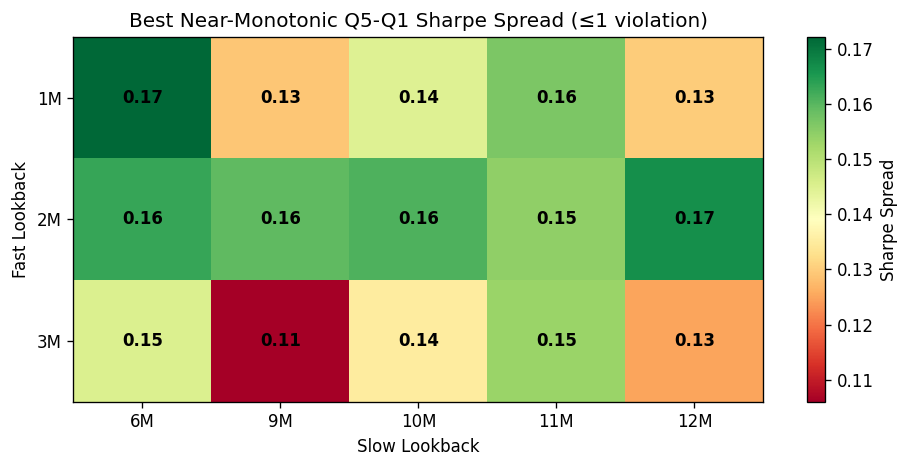

In [11]:
# Visualize grid search results
# Pick best: strictly monotonic first, then ≤1 violation, then best overall
mono_results = grid_results[grid_results["is_monotonic"]]
near_results = grid_results[grid_results["mono_violations"] <= 1]

if len(mono_results) > 0:
    best = mono_results.iloc[0]
    label = "monotonic"
elif len(near_results) > 0:
    best = near_results.iloc[0]
    label = f"near-monotonic ({int(best['mono_violations'])} violation)"
else:
    best = grid_results.iloc[0]
    label = f"{int(best['mono_violations'])} violations"

print(f"Best combo ({label}): "
      f"Fast={int(best['fast_months'])}M, Slow={int(best['slow_months'])}M, "
      f"w_slow={best['w_slow']:.1f}, w_fast={best['w_fast']:.1f}")
print(f"  Q1→Q5 Sharpe: {best['sharpe_Q1']:.3f} → {best['sharpe_Q2']:.3f} → "
      f"{best['sharpe_Q3']:.3f} → {best['sharpe_Q4']:.3f} → {best['sharpe_Q5']:.3f}")
print(f"  Spread: {best['sharpe_spread']:.3f}")

# Heatmap: for each (fast, slow) pair, show best sharpe_spread among ≤1 violation combos
pivot_src = near_results if len(near_results) > 0 else grid_results
hm_pivot = pivot_src.groupby(["fast_months", "slow_months"])["sharpe_spread"].max().unstack()

if not hm_pivot.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(hm_pivot.values, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(len(hm_pivot.columns)))
    ax.set_xticklabels([f"{int(c)}M" for c in hm_pivot.columns])
    ax.set_yticks(range(len(hm_pivot.index)))
    ax.set_yticklabels([f"{int(r)}M" for r in hm_pivot.index])
    ax.set_xlabel("Slow Lookback")
    ax.set_ylabel("Fast Lookback")
    ax.set_title("Best Near-Monotonic Q5-Q1 Sharpe Spread (≤1 violation)")

    for i in range(len(hm_pivot.index)):
        for j in range(len(hm_pivot.columns)):
            val = hm_pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, fontweight="bold")

    plt.colorbar(im, ax=ax, label="Sharpe Spread")
    plt.tight_layout()
    plt.show()

Selected: #0 → Fast=1M, Slow=6M, w_slow=0.5, w_fast=0.5  (violations=1, spread=0.172)


,ticker,name,ret_fast,ret_slow,rank_slow,rank_fast,rank_composite,quintile
58,372330.KS,HangSengTech,0.020619,-0.152657,3.0,6.0,4.5,Q1
1009,IGV,Software,0.061836,-0.264133,1.0,9.0,5.0,Q1
3133,XAR,Aerospace,0.003662,0.026526,7.0,3.0,5.0,Q1
2963,USMV,MinVol,0.011214,0.014768,6.0,4.0,5.0,Q1
2489,SKYY,CloudComputing,0.077816,-0.172784,2.0,11.0,6.5,Q2
1745,MGV,Value,0.035323,0.105351,11.0,8.0,9.5,Q2
2148,QUAL,Quality,0.073510,0.054423,9.0,10.0,9.5,Q2
508,GDX,GoldMiners,-0.035197,0.237622,18.0,2.0,10.0,Q2
2317,SCHD,Dividend,0.020535,0.192440,16.0,5.0,10.5,Q3
274,BOTZ,Robot,0.133654,-0.000195,5.0,16.0,10.5,Q3


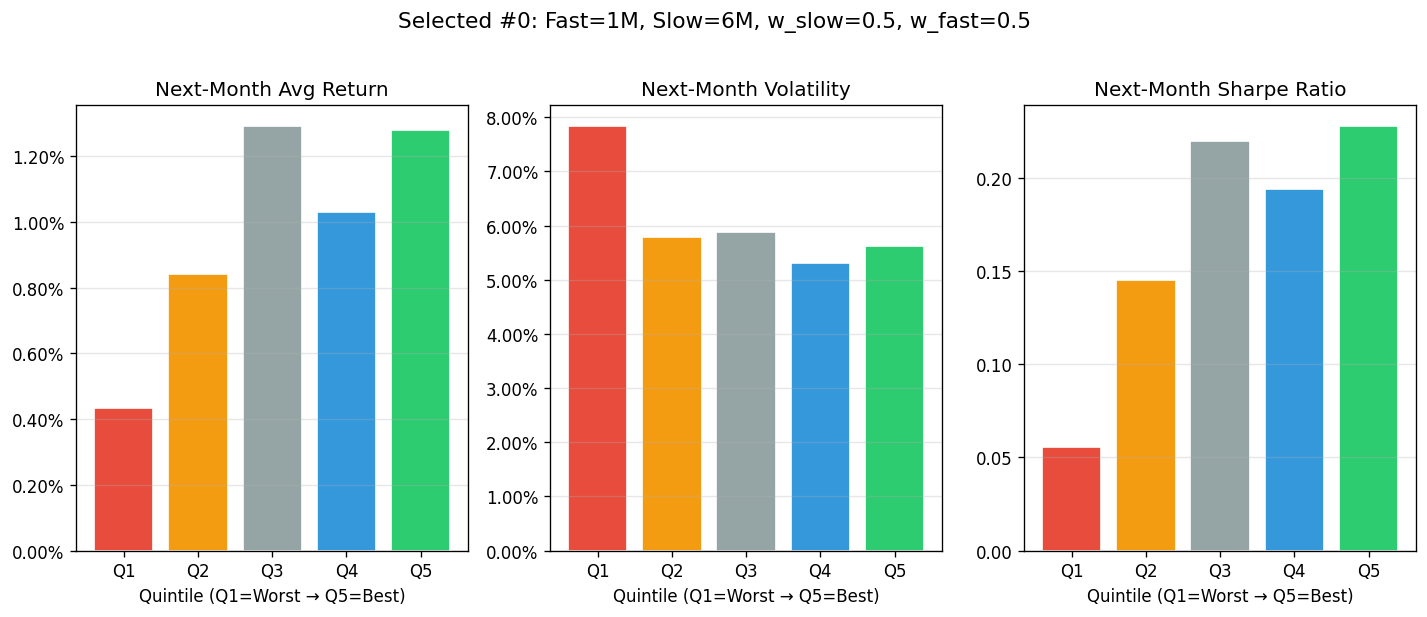

In [12]:
# ---- Select combo from near-monotonic results (0-indexed from table above) ----
selected_rank = 0  # Change this: 0 = 1st row, 2 = 3rd row, etc.

# Rerun quintile analysis with selected combo from grid search
sel = near_mono.iloc[selected_rank]
sel_fast = int(sel["fast_months"])
sel_slow = int(sel["slow_months"])
sel_ws = sel["w_slow"]
sel_wf = sel["w_fast"]

print(f"Selected: #{selected_rank} → Fast={sel_fast}M, Slow={sel_slow}M, "
      f"w_slow={sel_ws:.1f}, w_fast={sel_wf:.1f}  "
      f"(violations={int(sel['mono_violations'])}, spread={sel['sharpe_spread']:.3f})")

sel_signals = calc_momentum_signals(monthly_ret_multi, fast_months=sel_fast, slow_months=sel_slow)
sel_q_latest, sel_q_stats = calc_quintile_from_signals(
    monthly_ret_multi, sel_signals, w_slow=sel_ws, w_fast=sel_wf
)

# Show assignments
sel_q_latest["name"] = sel_q_latest["ticker"].map(ticker_names)
display(sel_q_latest[["ticker", "name", "ret_fast", "ret_slow",
                       "rank_slow", "rank_fast", "rank_composite", "quintile"]]
        .sort_values("rank_composite"))

# Chart
q_labels = [f"Q{i}" for i in range(1, 6)]
q_colors = ["#e74c3c", "#f39c12", "#95a5a6", "#3498db", "#2ecc71"]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].bar(q_labels, sel_q_stats.loc[q_labels, "mean"], color=q_colors, edgecolor="white")
axes[0].set_title("Next-Month Avg Return")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(q_labels, sel_q_stats.loc[q_labels, "std"], color=q_colors, edgecolor="white")
axes[1].set_title("Next-Month Volatility")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(q_labels, sel_q_stats.loc[q_labels, "sharpe"], color=q_colors, edgecolor="white")
axes[2].set_title("Next-Month Sharpe Ratio")
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].grid(axis="y", alpha=0.3)

for ax in axes:
    ax.set_xlabel("Quintile (Q1=Worst → Q5=Best)")

plt.suptitle(f"Selected #{selected_rank}: Fast={sel_fast}M, Slow={sel_slow}M, "
             f"w_slow={sel_ws:.1f}, w_fast={sel_wf:.1f}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()